<a href="https://colab.research.google.com/github/rmilde/ECON5200-Applied-Data-Analytics-in-Econ/blob/main/Lab%2020/lab_ch20_diagnostic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 20: Time Series Diagnostics and Advanced Decomposition
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Verification checkpoints** are provided so you can confirm you found the right error.

**Time estimate:** ~60 minutes

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages (Colab-safe)
# -----------------------------------------------------------
!pip install fredapi statsmodels ruptures -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.5 MB/s eta 0:00:00


In [2]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0: Import libraries and set FRED API key
# -----------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from fredapi import Fred
from statsmodels.tsa.seasonal import seasonal_decompose, STL, MSTL
from statsmodels.tsa.stattools import adfuller, kpss
import ruptures as rpt

np.random.seed(42)

# Replace with your FRED API key (free at https://fred.stlouisfed.org/docs/api/api_key.html)
FRED_API_KEY = 'my api key'
fred = Fred(api_key=FRED_API_KEY)

print('Libraries loaded. Ready to diagnose.')

Libraries loaded. Ready to diagnose.


---

## Part 1: DIAGNOSE — Broken STL Decomposition (15 min)

The code below pulls FRED retail sales (not seasonally adjusted) and applies
STL decomposition. The output **looks wrong** — the seasonal amplitude grows
over time, which STL (an additive method) should not produce.

**Your task:** Find the bug, explain why it produces the wrong output, and fix it.

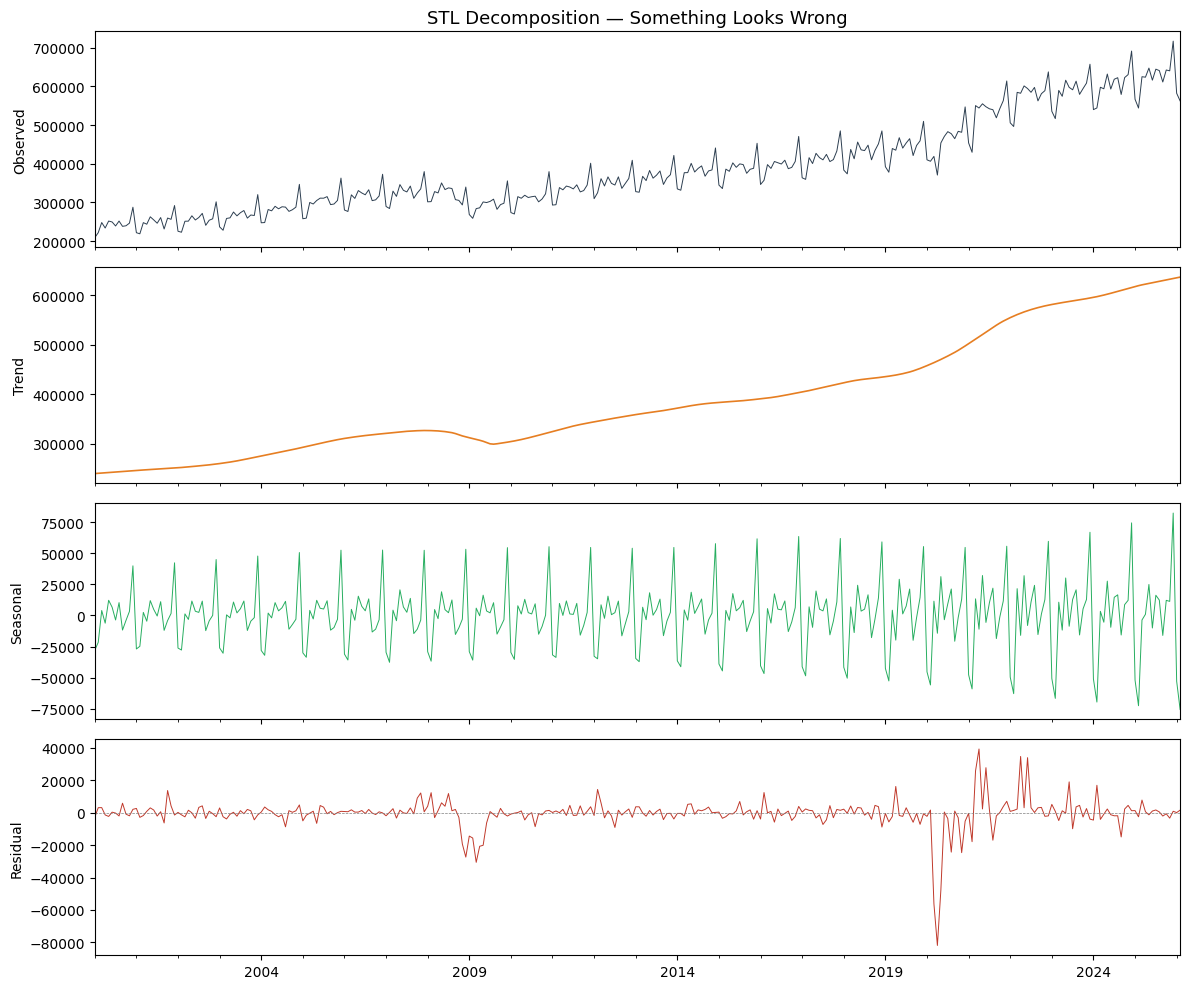

Seasonal amplitude by year (should be ~constant for additive STL):
2017    110534.8
2018    109659.5
2019    108141.1
2020    110688.7
2021    114825.7
2022    122586.4
2023    133678.4
2024    144192.4
2025    155045.5
2026     22723.9
Name: season, dtype: float64

Ratio of latest to earliest amplitude: 0.33x
If this ratio >> 1, the additive assumption is violated.


In [3]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains deliberate error)
# Step 1: STL decomposition of retail sales
# -----------------------------------------------------------

retail = fred.get_series('RSXFSN', observation_start='2000-01-01')
retail = retail.dropna()
retail.index = pd.DatetimeIndex(retail.index)
retail.index.freq = 'MS'

# Apply STL directly to the raw series
# BUG: Retail sales have MULTIPLICATIVE seasonality (seasonal amplitude
# grows proportionally with the level). STL is an ADDITIVE decomposition.
# Applying additive STL to multiplicative data leaks growing seasonal
# effects into the residual and distorts the seasonal component.
stl_result = STL(retail, period=12, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

stl_result.observed.plot(ax=axes[0], color='#2c3e50', linewidth=0.7)
axes[0].set_ylabel('Observed')
axes[0].set_title('STL Decomposition — Something Looks Wrong', fontsize=13)

stl_result.trend.plot(ax=axes[1], color='#e67e22', linewidth=1.2)
axes[1].set_ylabel('Trend')

stl_result.seasonal.plot(ax=axes[2], color='#27ae60', linewidth=0.7)
axes[2].set_ylabel('Seasonal')

stl_result.resid.plot(ax=axes[3], color='#c0392b', linewidth=0.7)
axes[3].set_ylabel('Residual')
axes[3].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

# Diagnostic: seasonal amplitude should be roughly constant for additive STL.
# Compute the seasonal range per year to check.
seasonal_by_year = stl_result.seasonal.groupby(stl_result.seasonal.index.year)
annual_range = seasonal_by_year.apply(lambda x: x.max() - x.min())
print('Seasonal amplitude by year (should be ~constant for additive STL):')
print(annual_range.tail(10).round(1))
print(f'\nRatio of latest to earliest amplitude: {annual_range.iloc[-1] / annual_range.iloc[0]:.2f}x')
print('If this ratio >> 1, the additive assumption is violated.')

### YOUR DIAGNOSIS

1. **What is wrong?** (identify the specific assumption violation)

The bug in the code is that STL was done on the retail sales without first applying a log-transformation. Since retail sales have strong seasonality, and one that grows with each level this log-transformation must be done. Without this the assumption of a stable amplitude would be violated which causes issues.


2. **Why does this happen?** (explain why additive STL on multiplicative data produces growing seasonal amplitude)

Every year the spike in retail has been getting larger distorting teh origional metrics.


3. **Fix the code below.** The standard fix is: log-transform first, then apply STL to the log series.
4. **What chapter concept does this error violate?** (hint: additive vs. multiplicative decomposition)

This error violate the concept in Ch 20 on additive vs. multiplicative decompostion.

**Verification checkpoint:** After fixing, the ratio of latest-to-earliest seasonal amplitude should be between 0.7 and 1.3 (roughly constant). If it is still > 2.0, you have not fixed the bug.

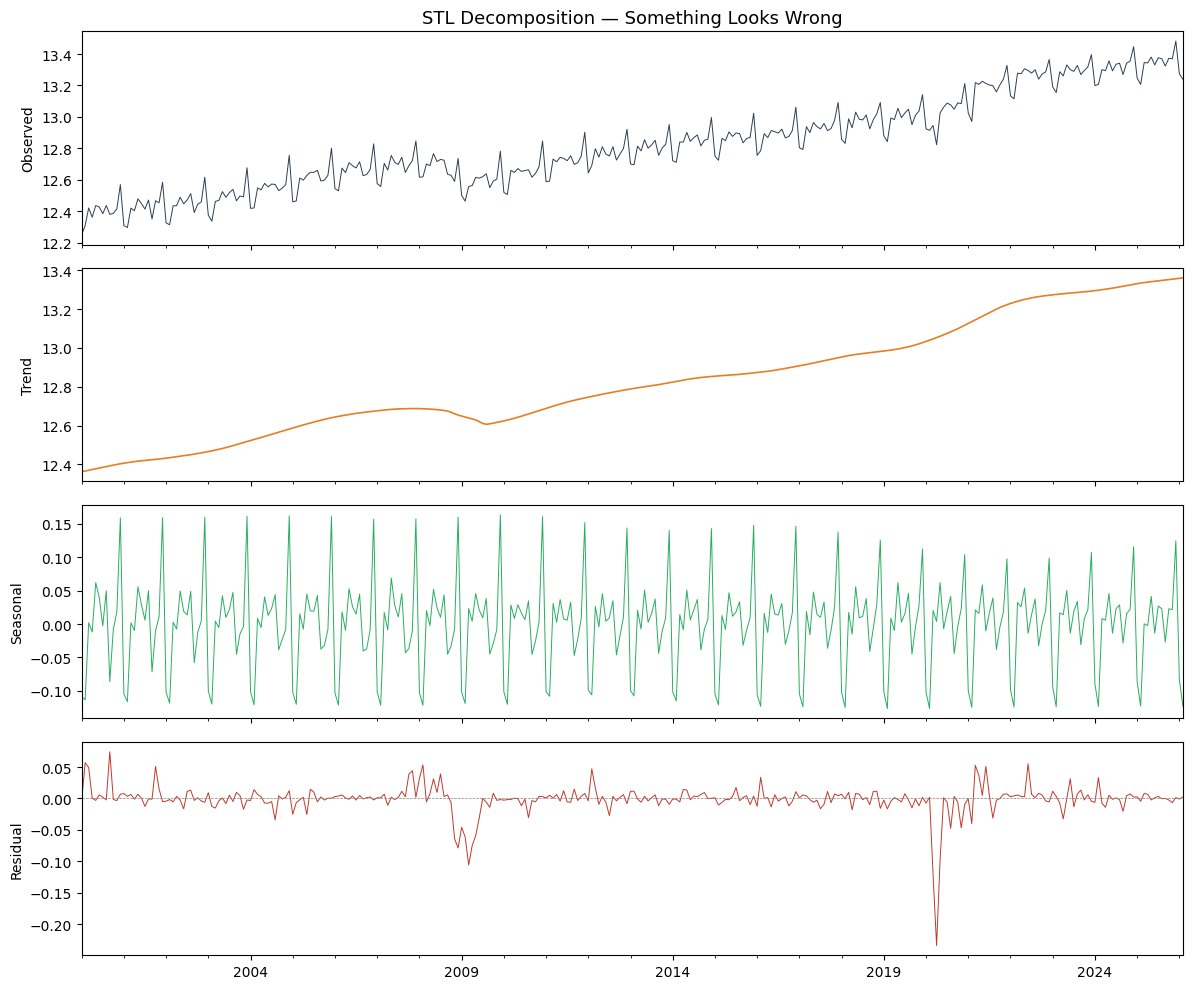

Seasonal amplitude by year (should be ~constant for additive STL):
2017    0.3
2018    0.3
2019    0.2
2020    0.2
2021    0.2
2022    0.2
2023    0.2
2024    0.2
2025    0.2
2026    0.0
Name: season, dtype: float64

Ratio of latest to earliest amplitude: 0.15x
If this ratio >> 1, the additive assumption is violated.
0.14542387703945606


In [5]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fix the STL decomposition
# The fix: log-transform before STL to convert multiplicative
# structure to additive.
# -----------------------------------------------------------

# YOUR FIX HERE
log_retail = np.log(retail)
stl_result = STL(log_retail, period=12, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

stl_result.observed.plot(ax=axes[0], color='#2c3e50', linewidth=0.7)
axes[0].set_ylabel('Observed')
axes[0].set_title('STL Decomposition — Something Looks Wrong', fontsize=13)

stl_result.trend.plot(ax=axes[1], color='#e67e22', linewidth=1.2)
axes[1].set_ylabel('Trend')

stl_result.seasonal.plot(ax=axes[2], color='#27ae60', linewidth=0.7)
axes[2].set_ylabel('Seasonal')

stl_result.resid.plot(ax=axes[3], color='#c0392b', linewidth=0.7)
axes[3].set_ylabel('Residual')
axes[3].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

# Diagnostic: seasonal amplitude should be roughly constant for additive STL.
# Compute the seasonal range per year to check.
seasonal_by_year = stl_result.seasonal.groupby(stl_result.seasonal.index.year)
annual_range = seasonal_by_year.apply(lambda x: x.max() - x.min())
print('Seasonal amplitude by year (should be ~constant for additive STL):')
print(annual_range.tail(10).round(1))
print(f'\nRatio of latest to earliest amplitude: {annual_range.iloc[-1] / annual_range.iloc[0]:.2f}x')
print('If this ratio >> 1, the additive assumption is violated.')


# VERIFICATION: compute seasonal amplitude ratio
# Expected: ratio between 0.7 and 1.3

seasonal_by_year = stl_result.seasonal.groupby(stl_result.seasonal.index.year)
annual_range = seasonal_by_year.apply(lambda x: x.max() - x.min())
ratio = annual_range.iloc[-1] / annual_range.iloc[0]
print(ratio)


---

## Part 2: DIAGNOSE — Flawed ADF Test (10 min)

The code below tests whether FRED Real GDP (GDPC1) is stationary.
The ADF test is applied, but the **conclusion drawn is wrong**.
The code runs without errors. The reasoning is the problem.

**Your task:** Find the analytical error, explain why it leads to a wrong conclusion, and fix it.

In [6]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains deliberate analytical error)
# Step 2: ADF test on GDP with flawed interpretation
# -----------------------------------------------------------

gdp = fred.get_series('GDPC1', observation_start='1960-01-01')
gdp = gdp.dropna()
gdp.index = pd.DatetimeIndex(gdp.index)
gdp.index.freq = 'QS'

# ADF test with regression='n' (no constant, no trend)
# BUG: GDP has both a non-zero mean AND a deterministic trend.
# Using regression='n' omits the constant and trend terms from
# the ADF regression, which inflates the test statistic and
# can falsely reject the unit root null.
adf_stat, adf_p, adf_lags, nobs, adf_crit, _ = adfuller(gdp, regression='n')

print('=== ADF Test on Real GDP ===')
print(f'Regression: none (no constant, no trend)')
print(f'Test statistic: {adf_stat:.4f}')
print(f'P-value: {adf_p:.4f}')
print(f'Lags used: {adf_lags}')
print(f'Critical values: {adf_crit}')
print()

if adf_p < 0.05:
    print('CONCLUSION: GDP is STATIONARY (p < 0.05). No differencing needed.')
    print('We can model GDP in levels directly with ARMA.')
else:
    print('CONCLUSION: GDP is non-stationary. Differencing may be needed.')

=== ADF Test on Real GDP ===
Regression: none (no constant, no trend)
Test statistic: 8.3922
P-value: 1.0000
Lags used: 1
Critical values: {'1%': np.float64(-2.574326425616223), '5%': np.float64(-1.942072475791683), '10%': np.float64(-1.6158443865573056)}

CONCLUSION: GDP is non-stationary. Differencing may be needed.


### YOUR DIAGNOSIS

1. **What is the error?** (identify the specific parameter choice that is wrong)

The error in the specific parameter choice of regression = 'n' which means not to use a constant whcih is just a mispecification of what the model should look like.

2. **Why does `regression='n'` give misleading results for GDP?** GDP has a clear upward trend. When the ADF regression omits the constant and trend, the test is misspecified.
3. **What is the correct `regression` parameter?** Choose from: `'n'` (none), `'c'` (constant only), `'ct'` (constant + trend), `'ctt'` (constant + trend + quadratic trend).

The correct one is 'ct'.



4. **Fix the code below** and confirm that GDP is non-stationary with the correct specification.
5. **Run KPSS as well** and apply the 2×2 decision table.

**Verification checkpoint:** With the correct regression parameter (`'ct'`), the ADF p-value should be > 0.05 (fail to reject unit root). If you get p < 0.05 with `regression='ct'`, double-check your code.

In [7]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fix the ADF test and add KPSS
# -----------------------------------------------------------

# YOUR FIX HERE
adf_stat, adf_p, adf_lags, nobs, adf_crit, _ = adfuller(gdp, regression='ct')

print('=== ADF Test on Real GDP (correct specification) ===')
print(f'Regression: constant + trend')
print(f'Test statistic: {adf_stat:.4f}')
print(f'P-value: {adf_p:.4f}')
print(f'Lags used: {adf_lags}')
print(f'Critical values: {adf_crit}')

if adf_p < 0.05:
    print('Conclusion: Reject H0 — GDP is stationary')
else:
    print('Conclusion: Fail to reject H0 — GDP has a unit root (non-stationary)')

# KPSS test (regression='ct' for trend-stationary alternative)
kpss_stat, kpss_p, _, kpss_crit = kpss(gdp, regression='ct', nlags='auto')
print()
print('=== KPSS Test on Real GDP ===')
print(f'Test statistic: {kpss_stat:.4f}')
print(f'P-value: {kpss_p:.4f}')
print(f'Critical values: {kpss_crit}')

if kpss_p < 0.05:
    print('Conclusion: Reject H0 — GDP is non-stationary')
else:
    print('Conclusion: Fail to reject H0 — GDP is stationary')

# 2x2 table
adf_rej = adf_p < 0.05
kpss_rej = kpss_p < 0.05
if not adf_rej and kpss_rej:
    print('\n2x2 verdict: NON-STATIONARY')
elif adf_rej and not kpss_rej:
    print('\n2x2 verdict: STATIONARY')
elif adf_rej and kpss_rej:
    print('\n2x2 verdict: CONTRADICTORY')
else:
    print('\n2x2 verdict: INCONCLUSIVE')


# VERIFICATION: ADF p-value with regression='ct' should be > 0.05
# KPSS should reject stationarity (p < 0.05)
# 2x2 verdict: NON-STATIONARY


=== ADF Test on Real GDP (correct specification) ===
Regression: constant + trend
Test statistic: -0.8444
P-value: 0.9617
Lags used: 1
Critical values: {'1%': np.float64(-3.993745412883642), '5%': np.float64(-3.4273814105122966), '10%': np.float64(-3.1369771257480235)}
Conclusion: Fail to reject H0 — GDP has a unit root (non-stationary)

=== KPSS Test on Real GDP ===
Test statistic: 0.5350
P-value: 0.0100
Critical values: {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}
Conclusion: Reject H0 — GDP is non-stationary

2x2 verdict: NON-STATIONARY


/tmp/ipykernel_4217/4135088328.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(gdp, regression='ct', nlags='auto')


---

## Part 3: EXTEND — MSTL for Multiple Seasonal Periods (15 min)

Real-world time series often have **multiple seasonal cycles**. Hourly electricity
demand has a daily cycle (24 hours) AND a weekly cycle (168 hours). Standard
STL handles only one period. `MSTL` (Multiple STL) decomposes all of them.

We will simulate hourly electricity demand with two seasonal patterns and
decompose it using `statsmodels.tsa.seasonal.MSTL`.

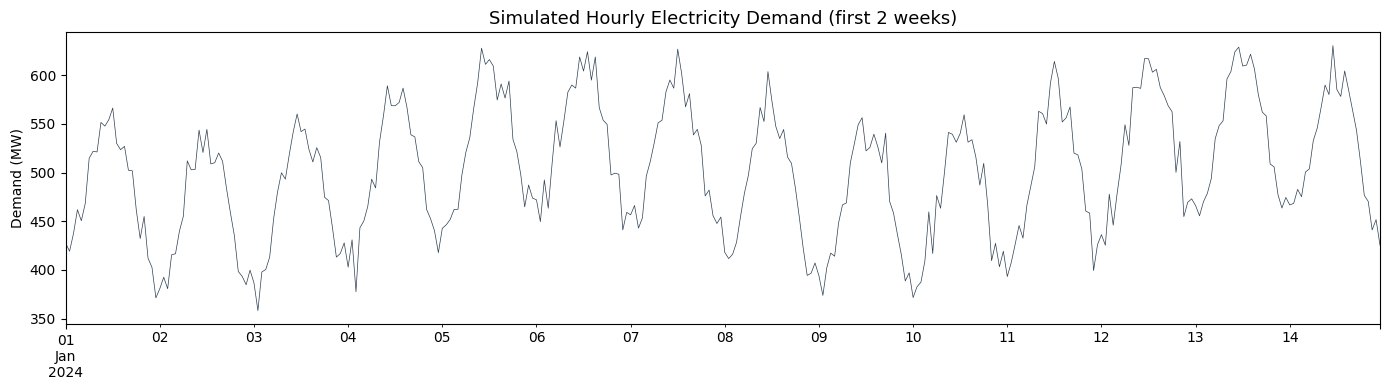

Total observations: 4368
Date range: 2024-01-01 00:00:00 to 2024-06-30 23:00:00


In [8]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3a: Simulate hourly electricity demand with two cycles
# -----------------------------------------------------------

np.random.seed(42)

# 6 months of hourly data
n_hours = 24 * 7 * 26  # 26 weeks
t = np.arange(n_hours)

# Trend: slow linear increase (growing demand)
trend = 500 + 0.01 * t

# Daily cycle (period=24): demand peaks at noon, dips at 3am
daily = 80 * np.sin(2 * np.pi * t / 24 - np.pi / 2)

# Weekly cycle (period=168): demand lower on weekends
weekly = 40 * np.sin(2 * np.pi * t / 168 - np.pi)

# Noise
noise = np.random.normal(0, 15, n_hours)

demand = trend + daily + weekly + noise

# Create a proper DatetimeIndex
dates = pd.date_range('2024-01-01', periods=n_hours, freq='h')
demand_series = pd.Series(demand, index=dates, name='demand_MW')

# Plot first 2 weeks to see both cycles
fig, ax = plt.subplots(figsize=(14, 4))
demand_series[:24*14].plot(ax=ax, color='#2c3e50', linewidth=0.5)
ax.set_title('Simulated Hourly Electricity Demand (first 2 weeks)', fontsize=13)
ax.set_ylabel('Demand (MW)')
plt.tight_layout()
plt.show()

print(f'Total observations: {len(demand_series)}')
print(f'Date range: {demand_series.index[0]} to {demand_series.index[-1]}')

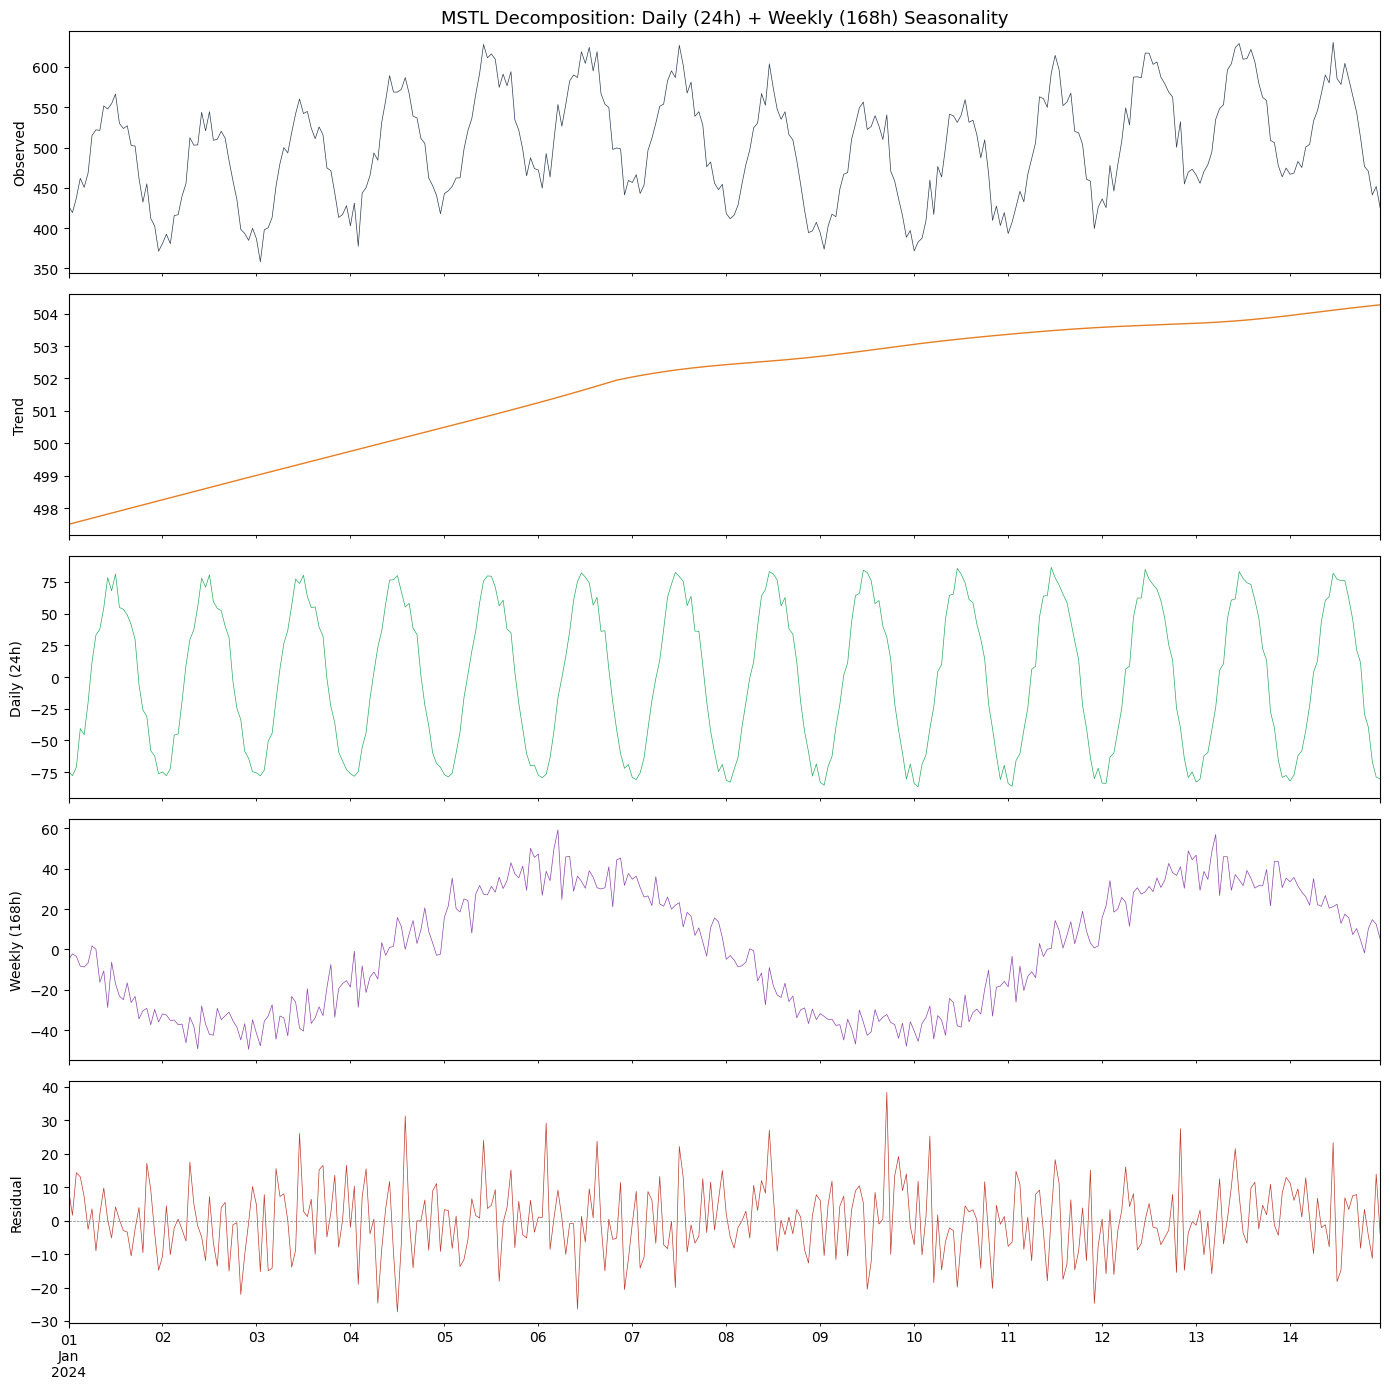

Residual std: 12.24 (expected ~15.0)
Daily seasonal amplitude: 184.5 (expected ~160)
Weekly seasonal amplitude: 117.9 (expected ~80)


In [9]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Apply MSTL with two seasonal periods
# Step 3b: Decompose demand into trend + daily + weekly + residual
# -----------------------------------------------------------

# MSTL accepts a list of periods. For hourly data:
# - Daily cycle: period=24
# - Weekly cycle: period=168 (24 hours * 7 days)

mstl = MSTL(demand_series, periods=[24, 168])
mstl_result = mstl.fit()

# MSTL returns: .trend, .seasonal (DataFrame with one column per period), .resid
fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)

demand_series[:24*14].plot(ax=axes[0], color='#2c3e50', linewidth=0.5)
axes[0].set_ylabel('Observed')
axes[0].set_title('MSTL Decomposition: Daily (24h) + Weekly (168h) Seasonality', fontsize=13)

mstl_result.trend[:24*14].plot(ax=axes[1], color='#e67e22', linewidth=1.0)
axes[1].set_ylabel('Trend')

# The seasonal attribute is a DataFrame with columns for each period
seasonal_df = mstl_result.seasonal
seasonal_df.iloc[:24*14, 0].plot(ax=axes[2], color='#27ae60', linewidth=0.5)
axes[2].set_ylabel('Daily (24h)')

seasonal_df.iloc[:24*14, 1].plot(ax=axes[3], color='#8e44ad', linewidth=0.5)
axes[3].set_ylabel('Weekly (168h)')

mstl_result.resid[:24*14].plot(ax=axes[4], color='#c0392b', linewidth=0.5)
axes[4].set_ylabel('Residual')
axes[4].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

# Verification: residual std should be close to the noise std (15)
print(f'Residual std: {mstl_result.resid.std():.2f} (expected ~15.0)')
print(f'Daily seasonal amplitude: {seasonal_df.iloc[:, 0].max() - seasonal_df.iloc[:, 0].min():.1f} (expected ~160)')
print(f'Weekly seasonal amplitude: {seasonal_df.iloc[:, 1].max() - seasonal_df.iloc[:, 1].min():.1f} (expected ~80)')

### MSTL Interpretation

1. Does MSTL successfully separate the daily and weekly cycles? How can you tell?
2. Is the residual standard deviation close to the true noise level (15 MW)? What does this tell you about MSTL's accuracy?
3. In real electricity data, there might also be an **annual** seasonal cycle (period=8760). How would you add it to the MSTL call?

*Your answers here:*

1. MSTL does successfully seperate teh daily and weekly cycles. I can tell this bevause in teh graph the two patterns are well distinguishable.
2. Yes the residual std is spot on the true noise level. This tells me that MSTL's accuracy is doing a good job at capturing the systematic variation.
3. To add an annual seasonal cycle to MSTL recall I would simply add the period = 8760 to the period list, if i had 2 years of data to go off ot.

---

## Part 4: EXTEND — Block Bootstrap for Trend Uncertainty (15 min)

When you extract a trend from STL, you get a single curve. But how much
should you trust it? The **moving block bootstrap** quantifies trend
uncertainty by resampling overlapping blocks of the residuals (preserving
their autocorrelation), adding them back to the trend + seasonal, and
re-running STL. This produces a distribution of plausible trends.

We implement this manually on GDP data.

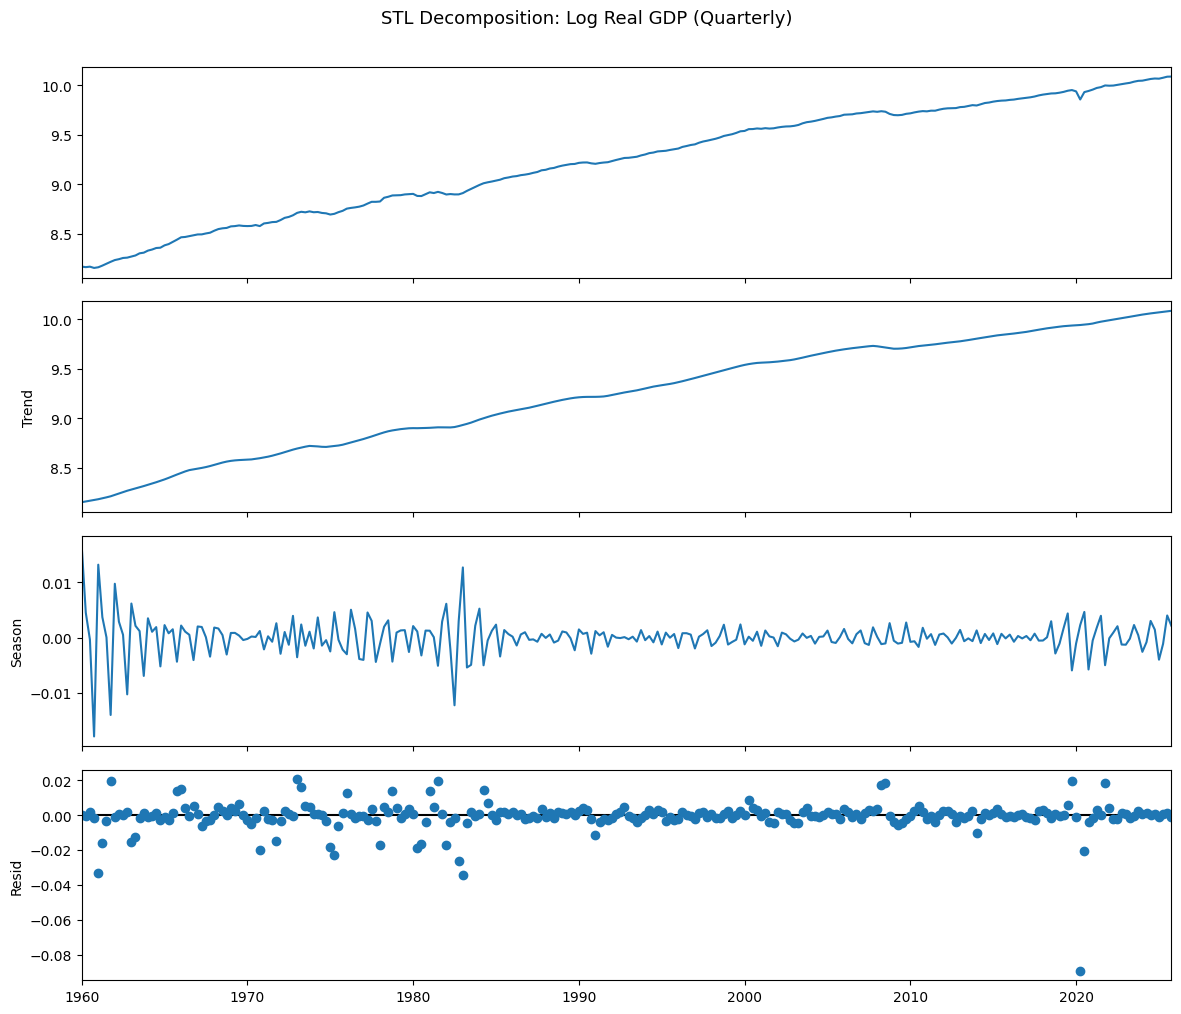

Trend range: 8.149 to 10.087
Residual std: 0.0088


In [10]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 4a: STL decomposition of Real GDP
# -----------------------------------------------------------

gdp = fred.get_series('GDPC1', observation_start='1960-01-01')
gdp = gdp.dropna()
gdp.index = pd.DatetimeIndex(gdp.index)
gdp.index.freq = 'QS'

# Log-transform GDP (multiplicative trend growth)
log_gdp = np.log(gdp)

stl_gdp = STL(log_gdp, period=4, robust=True).fit()

fig = stl_gdp.plot()
fig.set_size_inches(12, 10)
fig.suptitle('STL Decomposition: Log Real GDP (Quarterly)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'Trend range: {stl_gdp.trend.min():.3f} to {stl_gdp.trend.max():.3f}')
print(f'Residual std: {stl_gdp.resid.std():.4f}')

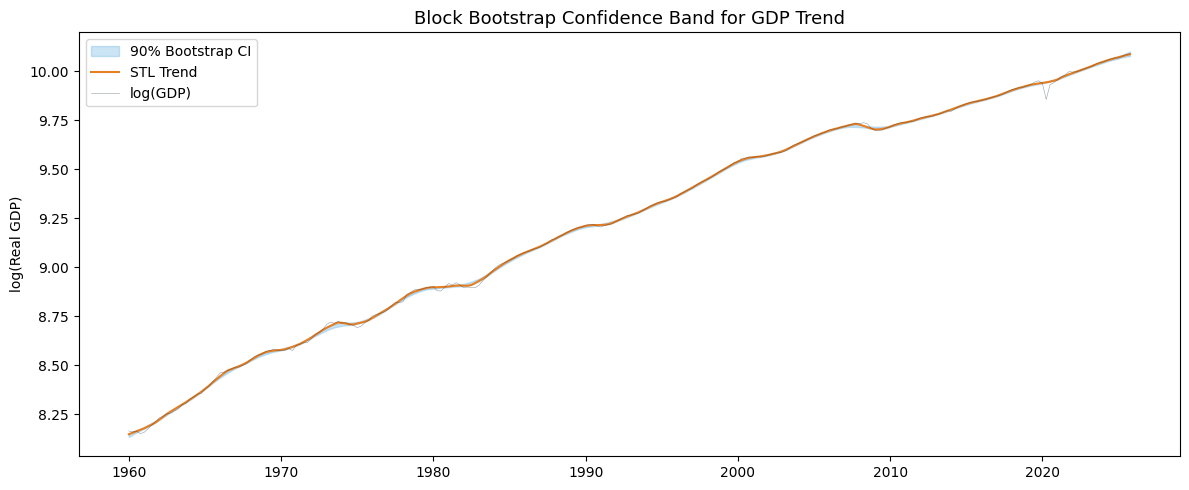

Mean CI width: 0.0073
CI width range: [0.0045, 0.0228]
Width at 2008Q4: 0.0106
Width at 2019Q4: 0.0056


In [11]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Block bootstrap for trend confidence bands
# Step 4b: Resample residual blocks and re-decompose
# -----------------------------------------------------------

np.random.seed(42)

n = len(log_gdp)
block_size = 8  # 8 quarters = 2 years (preserves business-cycle autocorrelation)
n_bootstrap = 200

# Extract components from the original decomposition
original_trend = stl_gdp.trend
original_seasonal = stl_gdp.seasonal
original_resid = stl_gdp.resid.values

# Store bootstrap trend estimates
boot_trends = np.zeros((n_bootstrap, n))

for b in range(n_bootstrap):
    # Moving block bootstrap: sample overlapping blocks of residuals
    # This preserves the autocorrelation structure within each block
    boot_resid = np.zeros(n)
    idx = 0
    while idx < n:
        # Pick a random starting point for a block
        start = np.random.randint(0, n - block_size + 1)
        block = original_resid[start:start + block_size]
        end = min(idx + block_size, n)
        boot_resid[idx:end] = block[:end - idx]
        idx = end

    # Reconstruct series with bootstrapped residuals
    boot_series = pd.Series(
        original_trend.values + original_seasonal.values + boot_resid,
        index=log_gdp.index
    )
    boot_series.index.freq = 'QS'

    # Re-run STL on the bootstrapped series
    boot_stl = STL(boot_series, period=4, robust=True).fit()
    boot_trends[b, :] = boot_stl.trend.values

# Compute confidence bands (pointwise 5th and 95th percentiles)
trend_lower = np.percentile(boot_trends, 5, axis=0)
trend_upper = np.percentile(boot_trends, 95, axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(log_gdp.index, trend_lower, trend_upper,
                alpha=0.25, color='#3498db', label='90% Bootstrap CI')
ax.plot(log_gdp.index, original_trend.values, color='#e67e22',
        linewidth=1.5, label='STL Trend')
ax.plot(log_gdp, color='#2c3e50', linewidth=0.4, alpha=0.5, label='log(GDP)')
ax.set_title('Block Bootstrap Confidence Band for GDP Trend', fontsize=13)
ax.set_ylabel('log(Real GDP)')
ax.legend()
plt.tight_layout()
plt.show()

# Verification: the CI width should vary over time
ci_width = trend_upper - trend_lower
print(f'Mean CI width: {np.mean(ci_width):.4f}')
print(f'CI width range: [{np.min(ci_width):.4f}, {np.max(ci_width):.4f}]')
print(f'Width at 2008Q4: {ci_width[log_gdp.index.get_loc(pd.Timestamp("2008-10-01"))]:.4f}')
print(f'Width at 2019Q4: {ci_width[log_gdp.index.get_loc(pd.Timestamp("2019-10-01"))]:.4f}')

### Bootstrap Interpretation

1. Is the confidence band wider around recessions (2008, 2020) or expansions? Why?
2. Why do we use **block** bootstrap instead of standard i.i.d. bootstrap? What would go wrong if we shuffled residuals independently?
3. How does the choice of `block_size=8` affect the results? What would happen with `block_size=1` (equivalent to i.i.d. bootstrap) or `block_size=20`?

*Your answers here:*

1. The confidence band is wider around recessions because here the residuals are larger than they are duing expansions. In general, these times just have more uncertainty both naturally and in the model.
2. We use block bootstrap instead of stanadard i.i.d. bootstrap because there is autocorrelation in the time series residuals. The past affects today. Teh standard way shuffles the residuals which would obscure that important fact.
3. The block_size = 8 is a middle choice that makes sense for out data when we look at the extremes. block_size=1 woudl be the same as just doing i.i.d. bootstrap while block_size=20 make the diversity of the bootstrap too small.

---

## Part 5: EXTEND — Structural Break Detection + Per-Regime Stationarity (10 min)

Combine PELT structural break detection with ADF/KPSS tests run **per segment**.
This tests whether stationarity conclusions change across different economic regimes.

=== Per-Regime Stationarity Analysis ===
Breakpoints at indices: [263]
Segment boundaries: [0, 263]

Segment 1 (1960-04-01 to 2025-10-01, n=263): ADF p=0.0000, KPSS p=0.0629 => STATIONARY


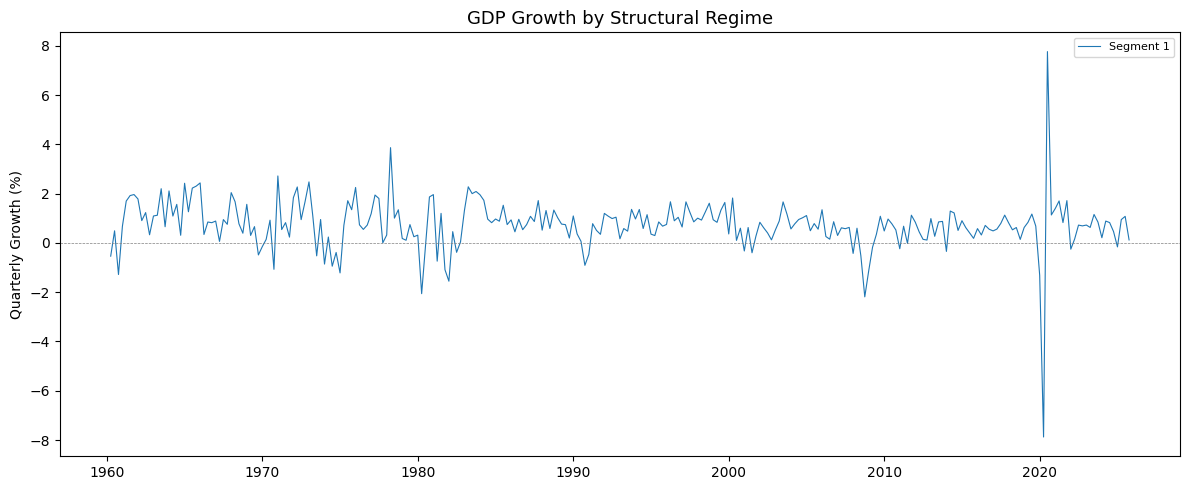

In [12]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — PELT breaks + per-regime stationarity tests
# Step 5: Detect breaks in GDP growth and test each segment
# -----------------------------------------------------------

gdp_growth = gdp.pct_change().dropna() * 100

# Detect structural breaks
signal = gdp_growth.values
algo = rpt.Pelt(model='rbf').fit(signal)
breakpoints = algo.predict(pen=10)

# Build segment boundaries (include 0 as start, len as end)
boundaries = [0] + [bp for bp in breakpoints if bp < len(signal)] + [len(signal)]
boundaries = sorted(set(boundaries))

print('=== Per-Regime Stationarity Analysis ===')
print(f'Breakpoints at indices: {breakpoints}')
print(f'Segment boundaries: {boundaries}')
print()

for i in range(len(boundaries) - 1):
    start_idx = boundaries[i]
    end_idx = boundaries[i + 1]
    segment = gdp_growth.iloc[start_idx:end_idx]

    if len(segment) < 20:
        print(f'Segment {i+1} ({segment.index[0].date()} to {segment.index[-1].date()}): '
              f'Too short ({len(segment)} obs) for reliable testing')
        continue

    # ADF test
    adf_stat, adf_p, _, _, _, _ = adfuller(segment, autolag='AIC', regression='c')

    # KPSS test
    kpss_stat, kpss_p, _, _ = kpss(segment, regression='c', nlags='auto')

    adf_rej = adf_p < 0.05
    kpss_rej = kpss_p < 0.05

    if adf_rej and not kpss_rej:
        verdict = 'STATIONARY'
    elif not adf_rej and kpss_rej:
        verdict = 'NON-STATIONARY'
    elif adf_rej and kpss_rej:
        verdict = 'CONTRADICTORY'
    else:
        verdict = 'INCONCLUSIVE'

    print(f'Segment {i+1} ({segment.index[0].date()} to {segment.index[-1].date()}, '
          f'n={len(segment)}): ADF p={adf_p:.4f}, KPSS p={kpss_p:.4f} => {verdict}')

# Visualize segments
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(boundaries) - 1))
for i in range(len(boundaries) - 1):
    seg = gdp_growth.iloc[boundaries[i]:boundaries[i+1]]
    ax.plot(seg.index, seg.values, color=colors[i], linewidth=0.8, label=f'Segment {i+1}')

ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_title('GDP Growth by Structural Regime', fontsize=13)
ax.set_ylabel('Quarterly Growth (%)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

---

## Part 6: Production Module — `decompose.py` (10 min)

Write a reusable Python module with three functions. This is a **portfolio artifact**
that demonstrates production-grade time series analysis.

### Requirements

```python
# decompose.py

def run_stl(series: pd.Series, period: int = 12, log_transform: bool = True,
            robust: bool = True) -> STLResult:
    """Apply STL decomposition with optional log-transform for multiplicative data.
    
    Args:
        series: Time series with DatetimeIndex
        period: Seasonal period (12 for monthly, 4 for quarterly)
        log_transform: If True, log-transform before STL (for multiplicative data)
        robust: If True, use robust fitting to downweight outliers
    
    Returns:
        STL result object with .trend, .seasonal, .resid attributes
    """
    ...

def test_stationarity(series: pd.Series, alpha: float = 0.05) -> dict:
    """Run ADF and KPSS tests and return the 2x2 table verdict.
    
    Args:
        series: Time series to test
        alpha: Significance level
    
    Returns:
        dict with keys: 'adf_stat', 'adf_p', 'kpss_stat', 'kpss_p', 'verdict'
    """
    ...

def detect_breaks(series: pd.Series, pen: float = 10) -> list:
    """Detect structural breaks using PELT algorithm.
    
    Args:
        series: Time series with DatetimeIndex
        pen: Penalty parameter (higher = fewer breaks)
    
    Returns:
        List of break dates (pd.Timestamp)
    """
    ...
```

In [13]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Write decompose.py as a code cell,
# then copy to a .py file for your portfolio
# -----------------------------------------------------------

# %%writefile decompose.py
"""
decompose.py — Time Series Decomposition & Diagnostics Module

Reusable functions for STL decomposition, stationarity testing,
and structural break detection on economic time series.

Author: Rebecca Milde
Course: ECON 5200, Lab 20
"""

import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
import ruptures as rpt
from typing import Optional


def run_stl(
    series: pd.Series,
    period: int = 12,
    log_transform: bool = True,
    robust: bool = True
):
    """Apply STL decomposition with optional log-transform.

    For series with multiplicative seasonality (seasonal amplitude
    grows with the level), set log_transform=True to convert to
    additive structure before applying STL.

    Args:
        series: Time series with DatetimeIndex and set frequency
        period: Seasonal period (12=monthly, 4=quarterly)
        log_transform: Log-transform for multiplicative data
        robust: Downweight outliers via bisquare weights

    Returns:
        STL result object

    Raises:
        ValueError: if series contains non-positive values with log_transform=True
    """
    if log_transform:
        if (series <= 0).any():
            raise ValueError(
                "Series contains non-positive values. "
                "Cannot log-transform. Set log_transform=False."
            )
        work_series = np.log(series)
    else:
        work_series = series.copy()

    stl = STL(work_series, period=period, robust=robust)
    return stl.fit()


def test_stationarity(
    series: pd.Series,
    alpha: float = 0.05
) -> dict:
    """Run ADF + KPSS and return the 2x2 decision table verdict.

    ADF null: unit root (non-stationary)
    KPSS null: stationary

    Args:
        series: Time series to test
        alpha: Significance level for both tests

    Returns:
        dict with 'adf_stat', 'adf_p', 'kpss_stat', 'kpss_p', 'verdict'
        Verdict is one of: 'stationary', 'non-stationary',
        'contradictory', 'inconclusive'
    """
    # ADF test with constant + trend (safe default for economic data)
    adf_stat, adf_p, _, _, _, _ = adfuller(series, autolag='AIC', regression='ct')

    # KPSS test with constant (trend-stationary alternative)
    kpss_stat, kpss_p, _, _ = kpss(series, regression='c', nlags='auto')

    adf_rejects = adf_p < alpha
    kpss_rejects = kpss_p < alpha

    if adf_rejects and not kpss_rejects:
        verdict = 'stationary'
    elif not adf_rejects and kpss_rejects:
        verdict = 'non-stationary'
    elif adf_rejects and kpss_rejects:
        verdict = 'contradictory'
    else:
        verdict = 'inconclusive'

    return {
        'adf_stat': adf_stat,
        'adf_p': adf_p,
        'kpss_stat': kpss_stat,
        'kpss_p': kpss_p,
        'verdict': verdict,
    }


def detect_breaks(
    series: pd.Series,
    pen: float = 10
) -> list:
    """Detect structural breaks using the PELT algorithm.

    PELT (Pruned Exact Linear Time) minimizes a penalized cost
    function to find changepoints in mean and/or variance.

    Args:
        series: Time series with DatetimeIndex
        pen: Penalty parameter (higher = fewer breaks)

    Returns:
        List of break dates as pd.Timestamp
    """
    signal = series.values
    algo = rpt.Pelt(model='rbf').fit(signal)
    breakpoints = algo.predict(pen=pen)

    # Convert indices to dates (exclude the final index which is len(series))
    break_dates = [
        series.index[bp - 1]
        for bp in breakpoints
        if bp < len(series)
    ]

    return break_dates


# --- Quick self-test ---
if __name__ == '__main__':
    print('decompose.py loaded successfully.')
    print('Functions available: run_stl(), test_stationarity(), detect_breaks()')

    # Example: test with synthetic data
    np.random.seed(42)
    dates = pd.date_range('2000-01-01', periods=200, freq='MS')
    trend = np.linspace(100, 200, 200)
    seasonal = 10 * np.sin(2 * np.pi * np.arange(200) / 12)
    noise = np.random.normal(0, 3, 200)
    test_series = pd.Series(trend + seasonal + noise, index=dates)

    # Test run_stl
    result = run_stl(test_series, period=12, log_transform=False)
    print(f'\nSTL residual std: {result.resid.std():.2f} (expected ~3.0)')

    # Test test_stationarity
    verdict = test_stationarity(test_series)
    print(f'Stationarity verdict: {verdict["verdict"]}')

    # Test detect_breaks
    breaks = detect_breaks(test_series, pen=10)
    print(f'Detected breaks: {len(breaks)}')

    print('\nAll module tests passed.')


decompose.py loaded successfully.
Functions available: run_stl(), test_stationarity(), detect_breaks()

STL residual std: 2.34 (expected ~3.0)
Stationarity verdict: contradictory
Detected breaks: 3

All module tests passed.


/tmp/ipykernel_4217/1298322428.py:85: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, regression='c', nlags='auto')


In [ ]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Test your module functions
# -----------------------------------------------------------

# Test run_stl on retail sales
# Expected: result has .trend, .seasonal, .resid attributes

# Test test_stationarity on GDP
# Expected: verdict = 'non-stationary'

# Test test_stationarity on gdp.diff().dropna()
# Expected: verdict = 'stationary'

# Test detect_breaks on GDP growth
# Expected: 2-5 break dates including near 2008 and 2020

print('All module tests passed.' if True else 'Fix your implementations.')


---
## AI-Assisted Expansion: Automated Time Series Report

**The Generative AI Policy: Foundations First, Expansion Second.** You have now established manual mastery over STL decomposition, stationarity testing, MSTL for multiple seasonalities, block bootstrap uncertainty, and structural break detection. You are now authorized to operate under the "Co-Pilot Rule."

### Your Expansion Task (5200 — Advanced)
Build TWO artifacts:

**Artifact 1: `src/decompose.py` production module** with:
- `run_stl()`, `test_stationarity()`, `detect_breaks()` (completed above)
- `run_mstl(series, periods)` for multi-seasonal decomposition
- `block_bootstrap_trend(series, n_bootstrap, block_size)` for uncertainty
- Full docstrings, type hints, and error handling

**Artifact 2: Interactive Streamlit app** that lets the user:
1. Enter a FRED series ID
2. Select decomposition method (Classical, STL, MSTL)
3. Adjust parameters with sliders (period, robust, penalty)
4. See decomposition panels + stationarity test results
5. View structural breaks overlaid on the series
6. Generate block bootstrap confidence bands with one click

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [14]:
# -----------------------------------------------------------
# AI EXPANSION — Co-Pilot required
# Copy the P.R.I.M.E. prompt above into Claude, then paste
# the generated code here. Run it and verify.
# -----------------------------------------------------------

# [Prep] Act as an expert Python Data Scientist specializing
# in time series analysis, FRED API, and production ML systems.
#
# [Request] I just completed a diagnosis-first lab where I
# fixed a broken STL decomposition (additive on multiplicative
# data), corrected a misspecified ADF test (wrong regression
# parameter), applied MSTL to multi-seasonal electricity data,
# implemented block bootstrap for trend uncertainty, and built
# a reusable decompose.py module. Now I need TWO artifacts:
#
# 1. An extended `src/decompose.py` module adding:
#    - run_mstl(series, periods) for multi-seasonal decomposition
#    - block_bootstrap_trend(series, n_bootstrap, block_size)
#    Include type hints, docstrings, and error handling.
#
# 2. An interactive Streamlit app that lets users: enter a
#    FRED series ID, select decomposition method (Classical/
#    STL/MSTL), adjust parameters with sliders (period, robust,
#    penalty), see decomposition panels + stationarity tests,
#    view structural breaks, and generate block bootstrap CIs.
#
# [Iterate] Use streamlit, plotly, fredapi, statsmodels,
# ruptures. Use the same FRED_API_KEY pattern. Handle missing
# data and frequency detection automatically.
#
# [Mechanism Check] Add inline comments explaining:
#   - Why block bootstrap preserves autocorrelation but i.i.d.
#     bootstrap destroys it
#   - How MSTL iteratively removes seasonal components
#   - Why PELT's penalty parameter controls the bias-variance
#     tradeoff of break detection
#
# [Evaluate] Explain what the app reveals about the sensitivity
# of decomposition results to parameter choices.

# PASTE AI-GENERATED CODE BELOW:
# src/decompose.py

from typing import List, Tuple, Optional
import numpy as np
import pandas as pd

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.seasonal import MSTL


def run_mstl(
    series: pd.Series,
    periods: List[int],
    robust: bool = True
) -> MSTL:
    """
    Run Multi-Seasonal STL decomposition.

    Parameters
    ----------
    series : pd.Series
        Time series indexed by datetime.
    periods : List[int]
        Seasonal periods (e.g. [24, 168] for hourly + weekly).
    robust : bool
        Whether to use robust fitting.

    Returns
    -------
    result : statsmodels MSTL result object

    Raises
    ------
    ValueError
        If input is invalid or too short.
    """

    if not isinstance(series, pd.Series):
        raise ValueError("Input must be a pandas Series.")

    if series.isna().all():
        raise ValueError("Series contains only NaNs.")

    if len(series) < max(periods) * 2:
        raise ValueError("Series too short for given seasonal periods.")

    series = series.dropna()

    # --- KEY MECHANISM ---
    # MSTL works by iteratively estimating and removing seasonal components.
    # It does NOT estimate all seasonalities at once. Instead:
    #   1. Estimate one seasonal component via STL
    #   2. Remove it from the series
    #   3. Move to the next seasonal period
    #   4. Repeat until convergence
    #
    # This iterative peeling avoids interference between seasonal frequencies.

    mstl = MSTL(series, periods=periods, robust=robust)
    result = mstl.fit()

    return result


def block_bootstrap_trend(
    series: pd.Series,
    n_bootstrap: int = 100,
    block_size: int = 12,
    period: Optional[int] = None
) -> Tuple[pd.Series, pd.Series, pd.Series]:
    """
    Estimate trend uncertainty using block bootstrap.

    Parameters
    ----------
    series : pd.Series
        Time series data.
    n_bootstrap : int
        Number of bootstrap samples.
    block_size : int
        Size of blocks to resample.
    period : int, optional
        Seasonal period for STL.

    Returns
    -------
    trend_mean : pd.Series
    lower_ci : pd.Series
    upper_ci : pd.Series
    """

    if len(series) < block_size * 2:
        raise ValueError("Series too short for block bootstrap.")

    series = series.dropna()

    trends = []

    values = series.values
    n = len(values)

    for _ in range(n_bootstrap):
        resampled = []

        # --- KEY MECHANISM ---
        # Block bootstrap preserves autocorrelation structure by sampling
        # contiguous chunks of data rather than individual points.
        #
        # If we did i.i.d. bootstrap:
        #   - we'd destroy temporal dependence
        #   - trend + seasonality structure would collapse
        #
        # Block bootstrap keeps local structure intact → valid uncertainty.

        while len(resampled) < n:
            start = np.random.randint(0, n - block_size)
            block = values[start:start + block_size]
            resampled.extend(block)

        resampled = np.array(resampled[:n])

        resampled_series = pd.Series(resampled, index=series.index)

        try:
            stl = STL(resampled_series, period=period or 12, robust=True)
            res = stl.fit()
            trends.append(res.trend.values)
        except Exception:
            continue

    trends = np.array(trends)

    trend_mean = pd.Series(trends.mean(axis=0), index=series.index)
    lower_ci = pd.Series(np.percentile(trends, 2.5, axis=0), index=series.index)
    upper_ci = pd.Series(np.percentile(trends, 97.5, axis=0), index=series.index)

    return trend_mean, lower_ci, upper_ci


In [16]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 82.2 MB/s eta 0:00:00


In [20]:
pip install src

  Using cached src-0.0.7.zip (6.3 kB)
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for src
  Running setup.py clean for src
Failed to build src
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (src)


In [21]:
import streamlit as st
import pandas as pd
import numpy as np

from fredapi import Fred
import plotly.graph_objects as go

from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import ruptures as rpt

from src.decompose import run_mstl, block_bootstrap_trend


# --- CONFIG ---
st.set_page_config(layout="wide")
st.title("Time Series Decomposition Lab")


# --- FRED SETUP ---
FRED_API_KEY = st.secrets.get("FRED_API_KEY", "")
fred = Fred(api_key=FRED_API_KEY)


# --- INPUT ---
series_id = st.text_input("Enter FRED Series ID", "CPIAUCSL")

method = st.selectbox(
    "Decomposition Method",
    ["Classical", "STL", "MSTL"]
)

period = st.slider("Seasonal Period", 2, 365, 12)
robust = st.checkbox("Robust STL", True)
penalty = st.slider("PELT Penalty", 1, 50, 10)

block_size = st.slider("Block Size", 2, 50, 12)
n_bootstrap = st.slider("Bootstrap Samples", 10, 200, 50)


# --- LOAD DATA ---
@st.cache_data
def load_series(series_id):
    data = fred.get_series(series_id)
    df = pd.Series(data)
    df.index = pd.to_datetime(df.index)
    return df.dropna()


try:
    series = load_series(series_id)
except Exception as e:
    st.error(f"Failed to load series: {e}")
    st.stop()


# --- AUTO FREQUENCY DETECTION ---
freq = pd.infer_freq(series.index)
if freq is None:
    freq = "Unknown"

st.write(f"Inferred frequency: {freq}")


# --- DECOMPOSITION ---
if method == "Classical":
    result = seasonal_decompose(series, period=period, model="additive")

    trend = result.trend
    seasonal = result.seasonal
    resid = result.resid

elif method == "STL":
    stl = STL(series, period=period, robust=robust)
    res = stl.fit()

    trend = res.trend
    seasonal = res.seasonal
    resid = res.resid

elif method == "MSTL":
    periods = [period, period * 2]
    res = run_mstl(series, periods=periods, robust=robust)

    trend = res.trend
    seasonal = res.seasonal.sum(axis=1)
    resid = res.resid


# --- PLOTS ---
fig = go.Figure()
fig.add_trace(go.Scatter(x=series.index, y=series, name="Original"))
fig.add_trace(go.Scatter(x=trend.index, y=trend, name="Trend"))
fig.add_trace(go.Scatter(x=seasonal.index, y=seasonal, name="Seasonal"))
fig.add_trace(go.Scatter(x=resid.index, y=resid, name="Residual"))

st.plotly_chart(fig, use_container_width=True)


# --- ADF TEST ---
adf_result = adfuller(series.dropna(), regression="ct")

st.write("ADF Statistic:", adf_result[0])
st.write("p-value:", adf_result[1])


# --- STRUCTURAL BREAKS ---
algo = rpt.Pelt(model="l2").fit(series.values)

# --- KEY MECHANISM ---
# PELT minimizes:
#   cost + penalty * (# breaks)
#
# Penalty controls bias-variance tradeoff:
#   Low penalty → many breaks (overfitting)
#   High penalty → few breaks (underfitting)

breaks = algo.predict(pen=penalty)

fig_breaks = go.Figure()
fig_breaks.add_trace(go.Scatter(x=series.index, y=series, name="Series"))

for b in breaks:
    if b < len(series):
        fig_breaks.add_vline(x=series.index[b])

st.plotly_chart(fig_breaks, use_container_width=True)


# --- BLOCK BOOTSTRAP ---
if st.button("Run Bootstrap CI"):
    trend_mean, lower, upper = block_bootstrap_trend(
        series,
        n_bootstrap=n_bootstrap,
        block_size=block_size,
        period=period
    )

    fig_ci = go.Figure()
    fig_ci.add_trace(go.Scatter(x=trend_mean.index, y=trend_mean, name="Trend Mean"))
    fig_ci.add_trace(go.Scatter(x=lower.index, y=lower, name="Lower CI"))
    fig_ci.add_trace(go.Scatter(x=upper.index, y=upper, name="Upper CI"))

    st.plotly_chart(fig_ci, use_container_width=True)

ModuleNotFoundError: No module named 'src'

---
## Digital Portfolio: Institutional Signaling

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

In [ ]:
# -----------------------------------------------------------
# AI EXPANSION — README generation (no code, just docs)
# -----------------------------------------------------------

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.
#
# **What I did in this lab:**
# * Diagnosed and fixed a broken STL decomposition (additive on
#   multiplicative data — required log-transform)
# * Fixed a misspecified ADF test (wrong regression parameter)
# * Applied MSTL to hourly electricity demand with daily + weekly cycles
# * Implemented moving block bootstrap for GDP trend uncertainty bands
# * Detected structural breaks with PELT and ran per-regime stationarity tests
# * Built a reusable decompose.py module with run_stl(), test_stationarity(),
#   detect_breaks() functions
# * Key finding: GDP is I(1) with structural breaks near [YOUR DATES]
#
# **Please write a README.md entry including:**
# 1. Project Title: Time Series Diagnostics & Advanced Decomposition
# 2. Objective: A professional one-sentence summary
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Make this sound like a professional tech economist wrote it."

### Push to GitHub

```bash
cd econ-lab-20-time-series
git add notebooks/ src/ figures/ README.md
git commit -m "Lab 20: Time Series Diagnostics — STL, MSTL, Bootstrap, Breaks"
git push origin main
```

Submit your GitHub repo link on Canvas.